In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import joblib

sys.path.append(str(Path.cwd().parent))
from helpers.data_loader import DataLoader

In [2]:
train = pd.read_parquet(DataLoader.transformed('train_t03.parquet'))
val   = pd.read_parquet(DataLoader.transformed('val_t03.parquet'))
test  = pd.read_parquet(DataLoader.transformed('test_t03.parquet'))

print(f'Train: {train.shape}  Val: {val.shape}  Test: {test.shape}')

Train: (109693, 17)  Val: (27483, 17)  Test: (34294, 17)


In [3]:
TARGET = 'Results'

X_train, y_train = train.drop(columns=TARGET), train[TARGET]
X_val,   y_val   = val.drop(columns=TARGET),   val[TARGET]
X_test,  y_test  = test.drop(columns=TARGET),  test[TARGET]

# scale_pos_weight for XGBoost = count(negative) / count(positive)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.4f}')

scale_pos_weight: 2.3869


In [4]:
def evaluate(model, X, y, split_name):
    y_pred       = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    cm           = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f'=== {split_name} ===')
    print(classification_report(y, y_pred, target_names=['Pass', 'Fail']))
    print(f'ROC-AUC:                            {roc_auc_score(y, y_pred_proba):.4f}')
    print(f'False Negative Rate (missed fails):  {fn/(fn+tp):.4f}')
    print(f'False Positive Rate (wasted insp.):  {fp/(fp+tn):.4f}')
    print()
    return y_pred_proba

In [5]:
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=0
)

In [6]:
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'XGBoost best iteration: {xgb.best_iteration}')
evaluate(xgb, X_train, y_train, 'XGBoost — Train')
xgb_val_proba = evaluate(xgb, X_val, y_val, 'XGBoost — Validation')

XGBoost best iteration: 172
=== XGBoost — Train ===
              precision    recall  f1-score   support

        Pass       0.91      0.76      0.83     77306
        Fail       0.59      0.82      0.68     32387

    accuracy                           0.78    109693
   macro avg       0.75      0.79      0.76    109693
weighted avg       0.81      0.78      0.78    109693

ROC-AUC:                            0.8763
False Negative Rate (missed fails):  0.1844
False Positive Rate (wasted insp.):  0.2397

=== XGBoost — Validation ===
              precision    recall  f1-score   support

        Pass       0.90      0.79      0.84     19211
        Fail       0.62      0.80      0.70      8272

    accuracy                           0.79     27483
   macro avg       0.76      0.79      0.77     27483
weighted avg       0.82      0.79      0.80     27483

ROC-AUC:                            0.8711
False Negative Rate (missed fails):  0.1997
False Positive Rate (wasted insp.):  0.2145



In [7]:
lgbm = LGBMClassifier(
    is_unbalance=True,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=-1
)

In [8]:
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[__import__('lightgbm').early_stopping(20, verbose=False)]
)

print(f'LightGBM best iteration: {lgbm.best_iteration_}')
evaluate(lgbm, X_train, y_train, 'LightGBM — Train')
lgbm_val_proba = evaluate(lgbm, X_val, y_val, 'LightGBM — Validation')

LightGBM best iteration: 67
=== LightGBM — Train ===
              precision    recall  f1-score   support

        Pass       0.90      0.75      0.82     77306
        Fail       0.57      0.80      0.67     32387

    accuracy                           0.76    109693
   macro avg       0.74      0.77      0.74    109693
weighted avg       0.80      0.76      0.77    109693

ROC-AUC:                            0.8613
False Negative Rate (missed fails):  0.1970
False Positive Rate (wasted insp.):  0.2541

=== LightGBM — Validation ===
              precision    recall  f1-score   support

        Pass       0.90      0.78      0.84     19211
        Fail       0.61      0.80      0.69      8272

    accuracy                           0.79     27483
   macro avg       0.76      0.79      0.77     27483
weighted avg       0.81      0.79      0.79     27483

ROC-AUC:                            0.8685
False Negative Rate (missed fails):  0.2014
False Positive Rate (wasted insp.):  0.2169


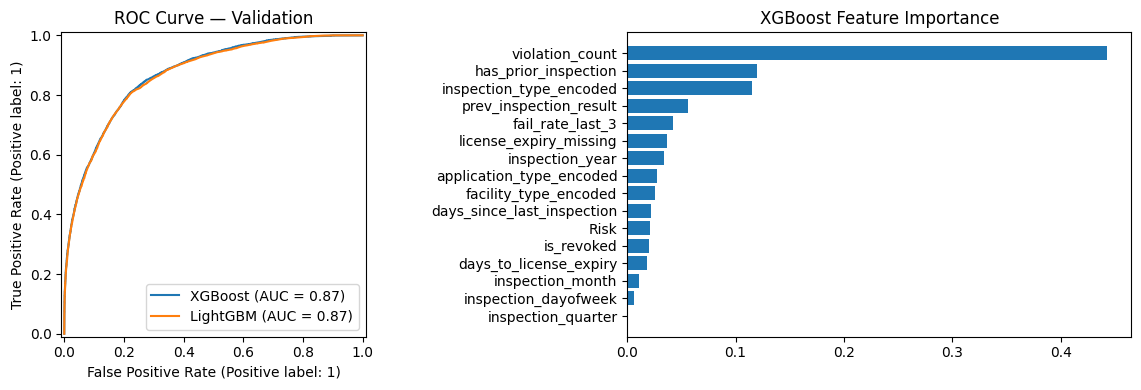

In [9]:
# Compare val ROC curves side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

RocCurveDisplay.from_predictions(y_val, xgb_val_proba,  ax=axes[0], name='XGBoost')
RocCurveDisplay.from_predictions(y_val, lgbm_val_proba, ax=axes[0], name='LightGBM')
axes[0].set_title('ROC Curve — Validation')

# Feature importance — XGBoost
imp_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance')

axes[1].barh(imp_df['feature'], imp_df['importance'])
axes[1].set_title('XGBoost Feature Importance')

plt.tight_layout()
plt.show()

In [ ]:
# Run only when done tuning — pick the better model from val results above
# xgb and light produced almost identical results
BEST_MODEL      = xgb        
BEST_MODEL_NAME = 'xgboost'  

evaluate(BEST_MODEL, X_test, y_test, f'{BEST_MODEL_NAME.upper()} — Test')

models_dir = Path.cwd().parent.parent / 'models'
models_dir.mkdir(exist_ok=True)
joblib.dump(BEST_MODEL, models_dir / f'{BEST_MODEL_NAME}.pkl')
print(f'Saved to {models_dir / BEST_MODEL_NAME}.pkl')

=== LIGHTGBM — Test ===
              precision    recall  f1-score   support

        Pass       0.88      0.85      0.86     17616
        Fail       0.85      0.88      0.86     16678

    accuracy                           0.86     34294
   macro avg       0.86      0.86      0.86     34294
weighted avg       0.86      0.86      0.86     34294

ROC-AUC:                            0.9299
False Negative Rate (missed fails):  0.1200
False Positive Rate (wasted insp.):  0.1521

Saved to d:\data-science\Food-Inspection\models\lightgbm.pkl


In [12]:
BEST_MODEL      = lgbm        
BEST_MODEL_NAME = 'lightgbm'  

evaluate(BEST_MODEL, X_test, y_test, f'{BEST_MODEL_NAME.upper()} — Test')

models_dir = Path.cwd().parent.parent / 'models'
models_dir.mkdir(exist_ok=True)
joblib.dump(BEST_MODEL, models_dir / f'{BEST_MODEL_NAME}.pkl')
print(f'Saved to {models_dir / BEST_MODEL_NAME}.pkl')

=== LIGHTGBM — Test ===
              precision    recall  f1-score   support

        Pass       0.88      0.85      0.86     17616
        Fail       0.85      0.88      0.86     16678

    accuracy                           0.86     34294
   macro avg       0.86      0.86      0.86     34294
weighted avg       0.86      0.86      0.86     34294

ROC-AUC:                            0.9299
False Negative Rate (missed fails):  0.1200
False Positive Rate (wasted insp.):  0.1521

Saved to d:\data-science\Food-Inspection\models\lightgbm.pkl
